<center>
<H2>CW01-1 Exercise 2.  (Hints)</H2><br>
---  or ---
<h4>How to stop worrying and love SymPy (Symbolic Python)
    </h4></center>


2.  **Classical Harmonic Motion**\
    Consider a classical Simple Harmonic Oscillator, as defined in the
    course notes, that consists of a frictionless particle of mass of
    $m$ bound by a conservative restoring force with a force constant
    $k$. Consider the case in which the particle is initially displaced
    from equilibrium by $x_0$ with a velocity of $v_0$ and released at
    time $t=0$.

    1.  What are the definitions and SI base units for the relevant
        variables and parameters in the problem?\
        These quantities are represented by the symbols:
        $x, p, T, V, m, k, t, \tau, \omega$, and $\nu$.

    2.  Give the following results in terms of $x_0, v_0, k,$ and $m$:

        1.  What is the angular frequency of oscillation, $\omega$, of
            the system?

        2.  What is the period of oscillation, $\tau$, of the system?

        3.  What is the total Energy, $E$, of the particle at $t=0$?

        4.  What is the total Energy of the particle at any time $t$?

    3.  Give the following results in terms of $x_0, v_0, m$ and
        $\omega$:

        1.  What is the maximum displacement of the particle from
            equilibrium, $x_{max}$?

        2.  At what position(s) does the particle exhibit Kinetic Energy
            exactly that of the maximum value, *i.e.* $T = T_{max}$?

        3.  What is the value of the maximum Kinetic Energy, $T_{max}$,
            of the particle?

        4.  How soon after release does the particle exhibit the maximum
            Kinetic Energy, *i.e.* $T(t) = T_{max}$? How many times a
            period does this happen?

    4.  1.  What is the time-averaged Potential Energy, $\overline{V}$,
            of the particle?

        2.  How soon after release does the particle exhibit Potential
            Energy exactly that of the average, *i.e.*
            $V(t) = \overline{V}$? How many times a period does this
            happen?

        3.  At what position(s) does the particle exhibit Potential
            Energy exactly that of the average, *i.e.*
            $V(x) = \overline{V}$?

    5.  Sketch the particle's position, momentum, Potential Energy, and
        Kinetic Energy as a function of time. Make two sketches of each
        requested quantity: one where $x_0 >0$ and $v_0 = 0$ and one
        where $x_0 =0$ and $v_0 > 0$

    6.  Sketch the spatial probability distribution of the particle,
        *i.e.*, the function that describes the time-averaged
        probability of finding the particle at any given position in
        space.\
        Label $\pm x_{max}$ on the sketch

### First, some general features of the Classical SHO 
and an introduction to Symbolic Python

#### Python is just a language.  What we really want are some libraries or *packages*.  This time the SymPy package package will be used extensively for *calculus*.

In [1]:
# The usual preamble;  Load the libraries, define symbols, etc.
import sympy as sym
import numpy as np
import matplotlib.pyplot as plt
from sympy.plotting import plot
sym.init_printing()
from sympy import Symbol, oo, pi, sin, cos, lambdify, latex,\
                    Derivative, diff, Integral, integrate,\
                    solve, expand, sqrt, simplify
from IPython.display import display, Math, Latex
plt.style.use(['dark_background'])

#### To perform symbolic Math, the *symbols* used will have to be defined

In [2]:
x=Symbol("x", real=True)
p=Symbol("p", real=True)
x0=Symbol("x_0", real=True)
v0=Symbol("v_0", real=True)
#p0=Symbol("p_0", real=True)
m=Symbol("m", real=True, positive=True, nonzero = True)
k=Symbol("k", real=True, positive=True, nonzero=True)
A=Symbol("A", real=True)
B=Symbol("B", real=True)
w=Symbol("omega", real=True, positive=True, nonzero = True)
t=Symbol("t", real=True, positive=True, nonzero = True)

#### Now, define some expressions to work with

In [3]:
Tp =(p**2)/(2*m)  # one particle kinetic energy
Tp

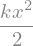

In [4]:
Vx = k*(x**2)/2   # harmonic potential energy 
Vx

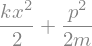

In [5]:
E_xp = Tp + Vx  # The total energy
E_xp

This output is an *expression*.  If we want to *display the equation*, we need to do some formatting.  The reason this will be more difficult that you think is because equating things has a special meaning in this environment

In [6]:
display(Math(r'E(x,p)='+latex(E_xp)))

<IPython.core.display.Math object>

In [7]:
xt = A*cos(w*t) + B*sin(w*t)  # General proposed solution to the classical SHO (will be shown to be correct)
display(Math(r'x(t)='+latex(xt)))

<IPython.core.display.Math object>

#### Use sympy to perform symbolic Calculus

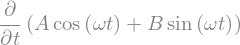

In [8]:
Derivative(xt,t)

####  Huh?  That didn't do anything but display what we desire.   We actually have to *do it !*

In [9]:
Derivative(xt,t).doit()

In [10]:
# pretty it up
display(Math(latex(Derivative(xt,t))+' = '+latex(Derivative(xt,t).doit())))

<IPython.core.display.Math object>

#### Do this all in one step with "diff"

In [11]:
diff(xt,t)

#### The Integral is the inverse of the derivative operation
We should get back where we started

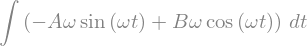

In [12]:
Integral(diff(xt,t),t)

In [13]:
Integral(diff(xt,t),t).doit()

#### Second derivatives?

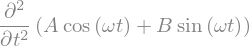

In [14]:
Derivative(xt,t,2)

In [15]:
Derivative(xt,t,2).doit()

### Now we can show that 
$$\large x(t) = A\cos{(\omega t )} + B\sin{(\omega t)}$$ 
#### is a <u>general</u> solution to the EOM (eq 1.4.3)
$$ \large \ddot{x} + \omega^2x = 0$$
#### where (eq 1.4.2)
$$\large \omega \equiv \sqrt{\frac{k}{m}}$$
(This is the definition of $\omega$)

### The period of oscillation is 
$$\large \tau = \frac{2\pi}{\omega} = 2\pi\sqrt{\frac{m}{k}}$$ 
which is simply the inverse linear frequency. Note the $2\pi$

In [16]:
# Demonstrate the solution.  One way is to show the LHS is zero
diff(xt,t,2)+(w**2)*xt

In [17]:
# More elegant?   Use a Boolean test of the equation
diff(xt,t,2)+(w**2)*xt == 0

True

### OK, Good, but what about $p(t)$?
#### Use time derivative of position to find the momentum trajectory (constant mass)
$$\large \because ~~ p = m \dot{x} = m\frac{dx}{dt}$$

In [18]:
pt = sym.simplify(m*diff(xt,t))  # Get momentum from position trajectory
display(Math(r'p(t)='+latex(pt)))

<IPython.core.display.Math object>

### This is great, but the intital conditions have no been applied.
#### Solve for the adjustable parameters ($A,B$) under *Arbitrary* initial (boundary) conditions, *i.e* 
<br>
$$\large x(t=0) \equiv x_0$$
<br>
$$\large p(t=0) \equiv p_0 = mv_0$$
<br>
The function "solve" finds the roots of an expression, finds the conditions under which it is zero

In [19]:
solve((xt.subs(t,0) - x0))  # Apply position initial condition; Find the roots of x(t) = x0 -> x(t) - x0 = 0

#### What is this?
"solve" returns a list, denoted by "[ ]" of *all* the roots it can find.

This list contains one root, where $A = x_0$

In [20]:
p0 = m*v0
p0

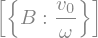

In [21]:
solve((pt.subs(t,0) - p0))  # Apply momentum initial condition

Here the root is $B = v_0/\omega = p_0/m \omega$

Substitute what was found into the expressions for $x(t)$ and $p(t)$ usuing ".subs"

In [22]:
xbc = xt.subs(A,x0).subs(B,v0/w)
display(Math(r'x(t)='+latex(xbc)))

<IPython.core.display.Math object>

In [23]:
pbc = pt.subs(A,x0).subs(B,v0/w)
display(Math(r'p(t)='+latex(pbc)))

<IPython.core.display.Math object>

#### Find Kinetic Energy as a function of time

In [24]:
Tt = simplify(expand(Tp.subs(p,pbc)))  # find Kinetic Energy as a function of time
display(Math(r'T(t)='+latex(Tt)))

<IPython.core.display.Math object>

#### ... and now the Potential Energy

In [25]:
Vt = simplify(expand(Vx.subs(x,xbc).subs(k,m*w**2)))  # find Potential Energy as a function of time
display(Math(r'V(t)='+latex(Vt)))

<IPython.core.display.Math object>

### This is nothing one couldn't do "by hand", but serves as a demonstration of what Python can do: <br> Calculus on command!

###  Note: The total energy is independent of time *and* depends explicitly on the initial conditions
Show this!

In [26]:
Etotal = expand(simplify(E_xp.subs(x,xbc).subs(p,pbc).subs(w,sqrt(k/m))))
display(Math(r'E(t)='+latex(Etotal)+r'\;=\;E(\,t=0\,)'))

<IPython.core.display.Math object>

### What is the maximum displacement?  <br> This happens where $V(x_{max}) = E_{total}$ !!

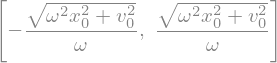

In [27]:
xmax_roots = solve((Vx-Etotal).subs(k,m*w**2),x)
xmax_roots

In [28]:
### Two roots (obviously);  Take the positive one for future use
xmax = xmax_roots[1]
display(Math("|x_{max}| = "+latex(xmax)))

<IPython.core.display.Math object>